In [ ]:
#Поиск пропущенных значений в каждом столбце 1.1

import pandas as pd

#загрузка данных
df = pd.read_csv('Medical_insurance.csv')

#счёт пропусков по каждому столбцу
missing = df.isnull().sum()

#вывод результата
if missing.sum() == 0:
    print("Пропущенных значений нет.")
else:
    print("Найдены пропущенные значения:")
    print(missing[missing > 0]) #названия столбцов и количество пропусков в них

Пропущенных значений нет.


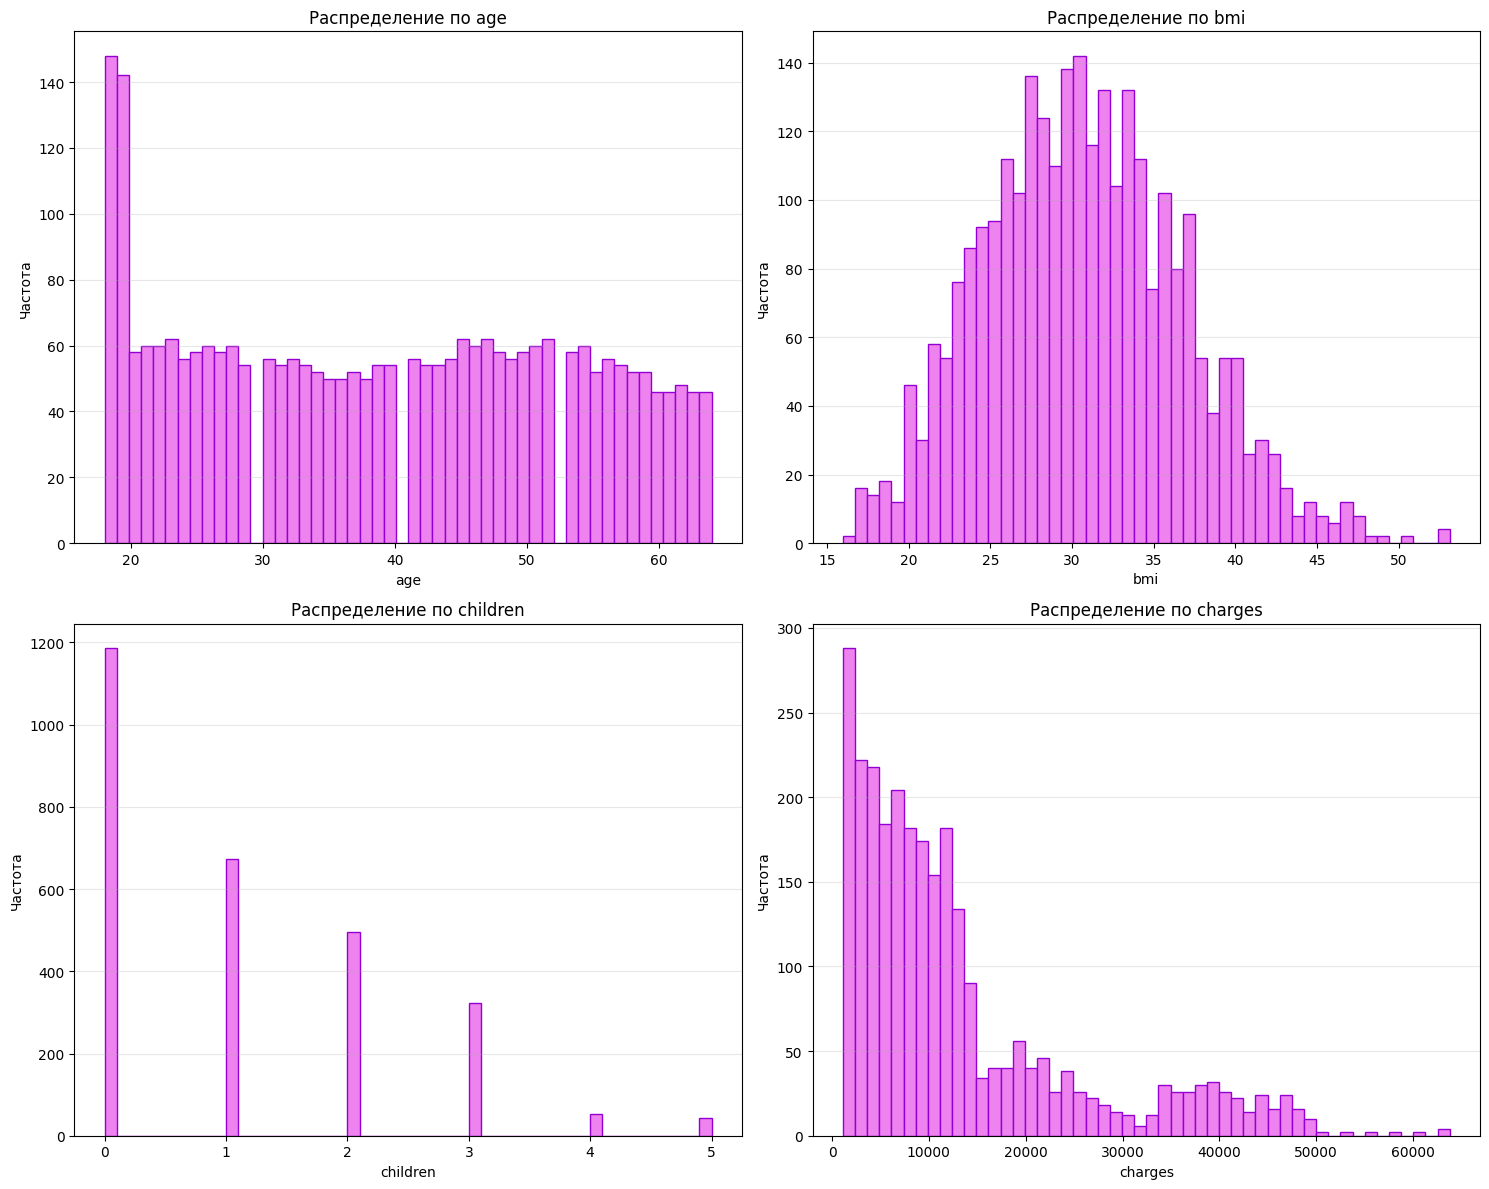

In [ ]:
#Построение диаграмм 1.2.1

import pandas as pd
import matplotlib.pyplot as plt

#загрузка данных
df = pd.read_csv('Medical_insurance.csv')

#признаки
numeric_cols = ['age', 'bmi', 'children', 'charges']

#общая сетка 4x2
plt.figure(figsize=(15, 12))

#числовые признаки (4 графика)
for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(2, 2, i) #расположение графиков
    plt.hist(df[col], bins=50, edgecolor='darkviolet', alpha=1, color='violet') #параметры графика
    plt.title(f'Распределение по {col}') #заголовок
    plt.xlabel(col) #название оси х
    plt.ylabel('Частота') #название оси y
    plt.grid(axis='y', alpha=0.3) #сетка (горизонтальные полоски)

plt.tight_layout() #корректировка расположения графиков
plt.show() #вывод графиков

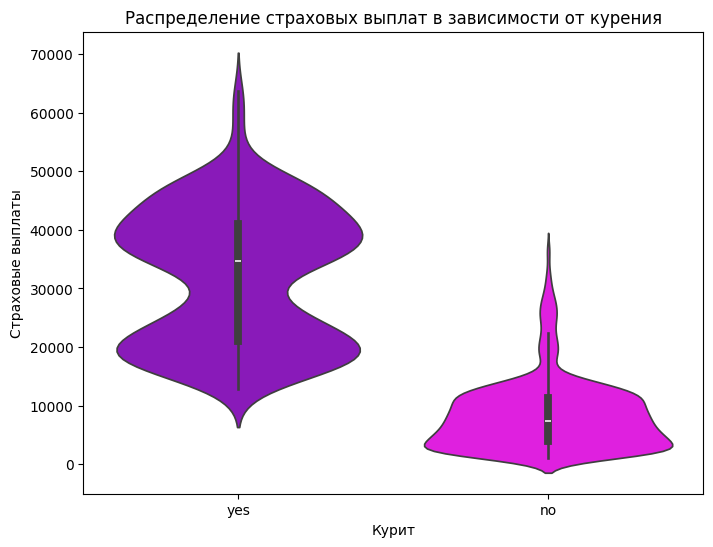

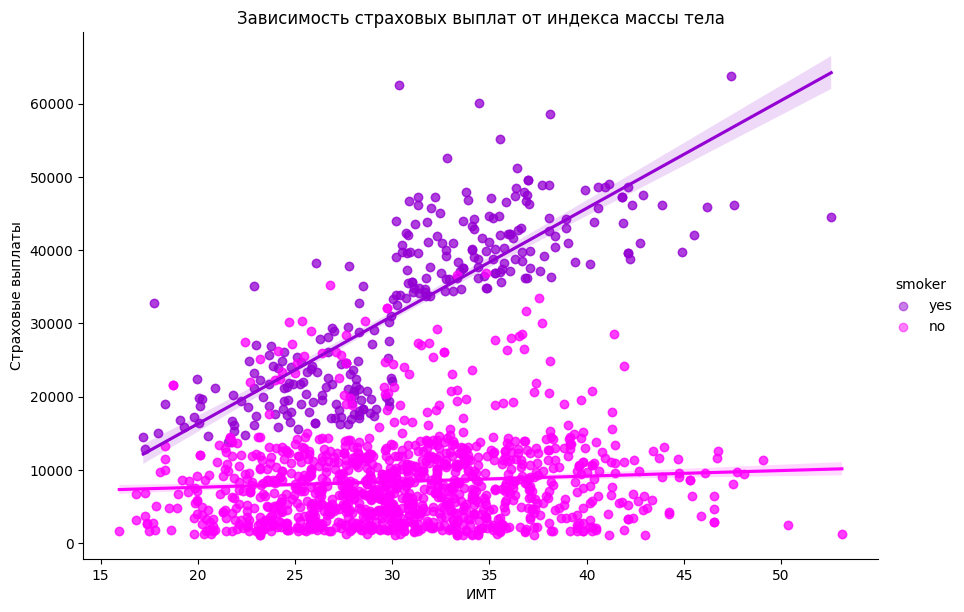

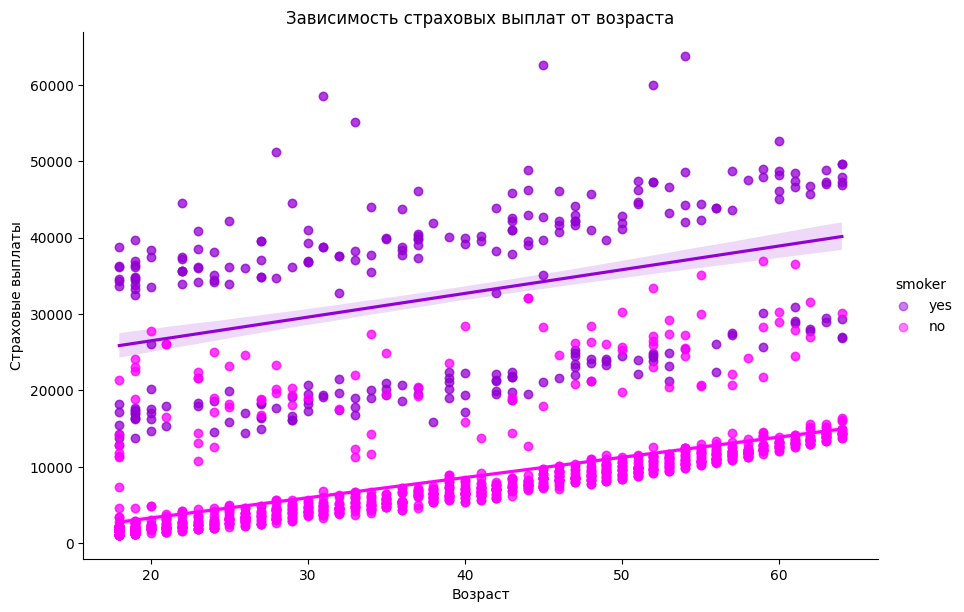

In [ ]:
#Визуализация с помощью Seaborn 1.2.2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#загрузка
df = pd.read_csv('Medical_insurance.csv')

plt.figure(figsize=(8, 6)) #создание общей сетки

#влияние курения на стоимость страховки
sns.violinplot(data=df, x='smoker', y='charges', hue='smoker', palette={'yes': 'darkviolet', 'no': 'Fuchsia'}, legend=False) #cкрипичный график и его параметры
plt.title('Распределение страховых выплат в зависимости от курения') #заголовок
plt.xlabel('Курит') #название оси х
plt.ylabel('Страховые выплаты') #название оси у
plt.show() #вывод графика

#взаимосвязь индекса массы тела и стоимости страховки с учётом курения
sns.lmplot(data=df, x='bmi', y='charges', hue='smoker', palette={'yes': 'darkviolet', 'no': 'Fuchsia'},
           scatter_kws={'alpha':0.5}, height=6, aspect=1.5) #диаграмма рассеяния с наложенной линией линейной регрессии и её параметры
plt.title('Зависимость страховых выплат от индекса массы тела') #заголовок
plt.xlabel('ИМТ') #название оси х
plt.ylabel('Страховые выплаты') #название оси у
plt.show() #вывод

#влияние возраста на стоимость страховки с разделением по курению
sns.lmplot(data=df, x='age', y='charges', hue='smoker', palette={'yes': 'darkviolet', 'no': 'Fuchsia'},
           scatter_kws={'alpha':0.5}, height=6, aspect=1.5) #диаграмма рассеяния с наложенной линией линейной регрессии и её параметры
plt.title('Зависимость страховых выплат от возраста') #заголовок
plt.xlabel('Возраст') #название оси х
plt.ylabel('Страховые выплаты') #название оси у
plt.show() #вывод

In [ ]:
#Визуализация признаков средствами библиотеки pyplot 1.2.3

import pandas as pd
import plotly.express as px

#загрузка данных
df = pd.read_csv('Medical_insurance.csv')

#график 1: 3D-диаграмма и её параметры
figure_1 = px.scatter_3d(df, x='bmi', y='children', z='charges',
                     color='smoker', symbol='sex',
                     title='Стоимость страховки от BMI и количества детей', color_discrete_map={'yes': 'fuchsia', 'no': 'darkviolet'})
figure_1.show() #вывод

#рафик 2: японские свечи по регионам и их параметры
figure_2 = px.box(df, x='region', y='charges', color='smoker',
              title='Стоимость страховки по регионам', color_discrete_map={'yes': 'fuchsia', 'no': 'darkviolet'})
figure_2.show() #вывод


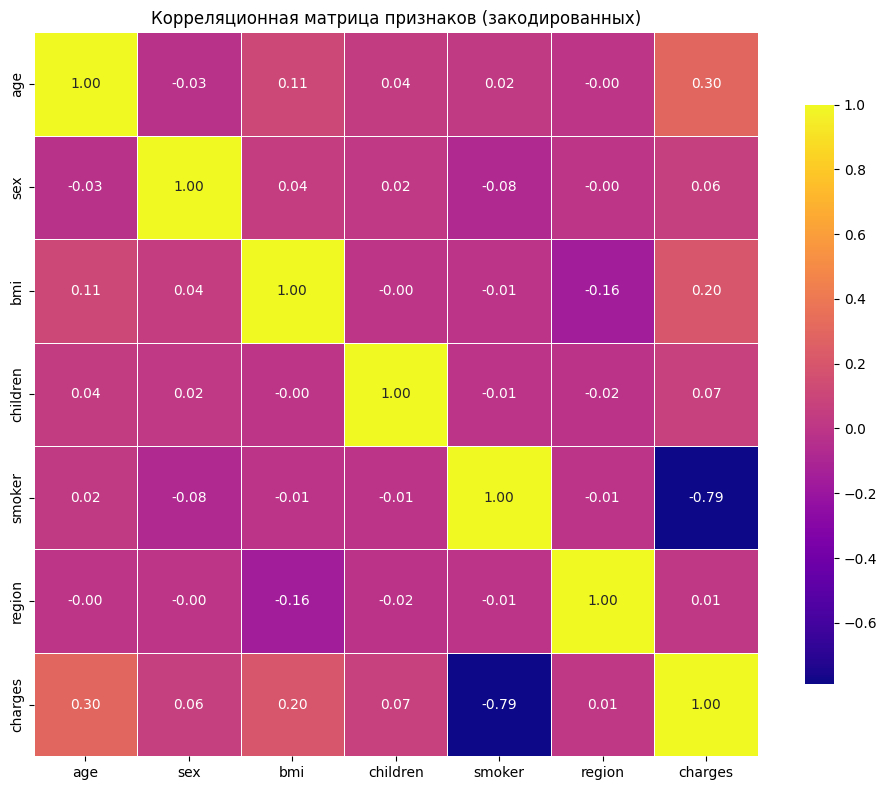

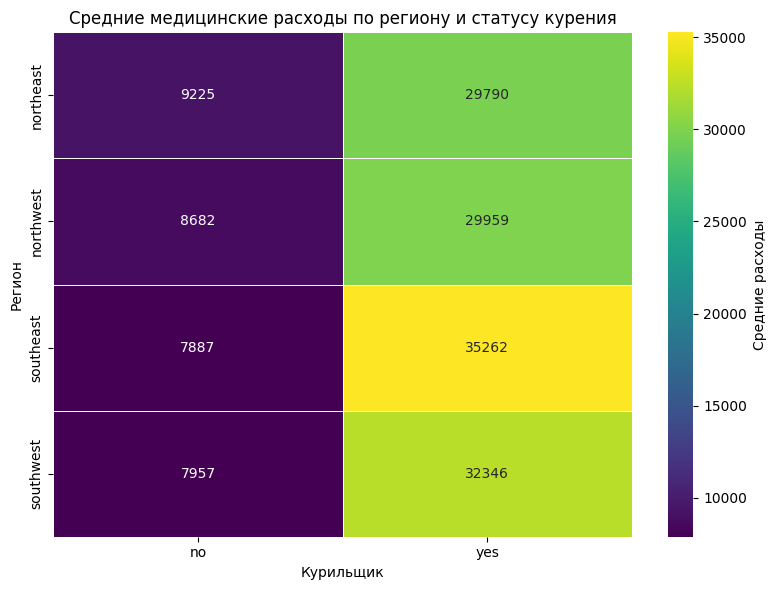

In [ ]:
#Построение тепловой карты 1.2.5

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#загрузка данных
df = pd.read_csv('Medical_insurance.csv')

#тепловая карта 1: Корреляция между признаками
df_corr = df.copy() #копия данных для кодирования
categorical_cols = ['sex', 'smoker', 'region']

#кодирование категориальных признаков с помощью pd.factorize
for col in categorical_cols:
    df_corr[col] = pd.factorize(df_corr[col])[0]

#вычисление корреляционной матрицы и построение тепловой карты
corr_matrix = df_corr.corr()
plt.figure(figsize=(10, 8)) #создание общей сетки
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='plasma',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}) #тепловая карта и её параметры
plt.title('Корреляционная матрица признаков (закодированных)') #заголовок
plt.tight_layout() #коррекция расположения
plt.show() #вывод

#тепловая карта 2: Средние расходы по региону и статусу курения

pivot = df.pivot_table(index='region', columns='smoker',
                       values='charges', aggfunc='mean')

plt.figure(figsize=(8, 6)) #создание общей сетки
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='viridis',
            linewidths=0.5, cbar_kws={'label': 'Средние расходы'}) #тепловая карта и её параметры
plt.title('Средние медицинские расходы по региону и статусу курения') #заголовок
plt.xlabel('Курильщик') #название оси х
plt.ylabel('Регион') #название оси у

plt.tight_layout() #коррекция
plt.show() #вывод

In [ ]:
#Устранение дубликатов строк 1.2.6

import pandas as pd

#загрузка данных из CSV файла
df = pd.read_csv('Medical_insurance.csv')

#проверка на дубликаты
duplicates = df[df.duplicated()]

#вывод результатов
if len(duplicates) > 0:
    print(f"Найдено дубликатов строк: {len(duplicates)}")

#удаление дубликатов
df_no_duplicates = df.drop_duplicates()

#сохранение очищенного файла
df_no_duplicates.to_csv('Medical_insurance_clean.csv', index=False)

print(f"Было строк: {len(df)}")
print(f"Стало строк: {len(df_no_duplicates)}")
print(f"Удалено дубликатов: {len(df) - len(df_no_duplicates)}")

df_clean = pd.read_csv('Medical_insurance_clean.csv')

#проверка на дубликаты
duplicates = df_clean[df_clean.duplicated()]

if len(duplicates) == 0:
    print("Очищенный файл не содержит дубликатов строк.")
else:
    print(f"В очищенном файле найдено дубликатов: {len(duplicates)}")
    print(duplicates.head())

Найдено дубликатов строк: 1435
Было строк: 2772
Стало строк: 1337
Удалено дубликатов: 1435
Очищенный файл не содержит дубликатов строк.



=== age ===
Границы: [-9.00, 87.00]
Количество выбросов: 0

=== bmi ===
Границы: [13.67, 47.32]
Количество выбросов: 9
Примеры выбросов:
       bmi
116  49.06
286  48.07
401  47.52
543  47.41
846  50.38

=== children ===
Границы: [-3.00, 5.00]
Количество выбросов: 0

=== charges ===
Границы: [-13120.72, 34524.78]
Количество выбросов: 139
Примеры выбросов:
       charges
14  39611.7577
19  36837.4670
23  37701.8768
29  38711.0000
30  35585.5760


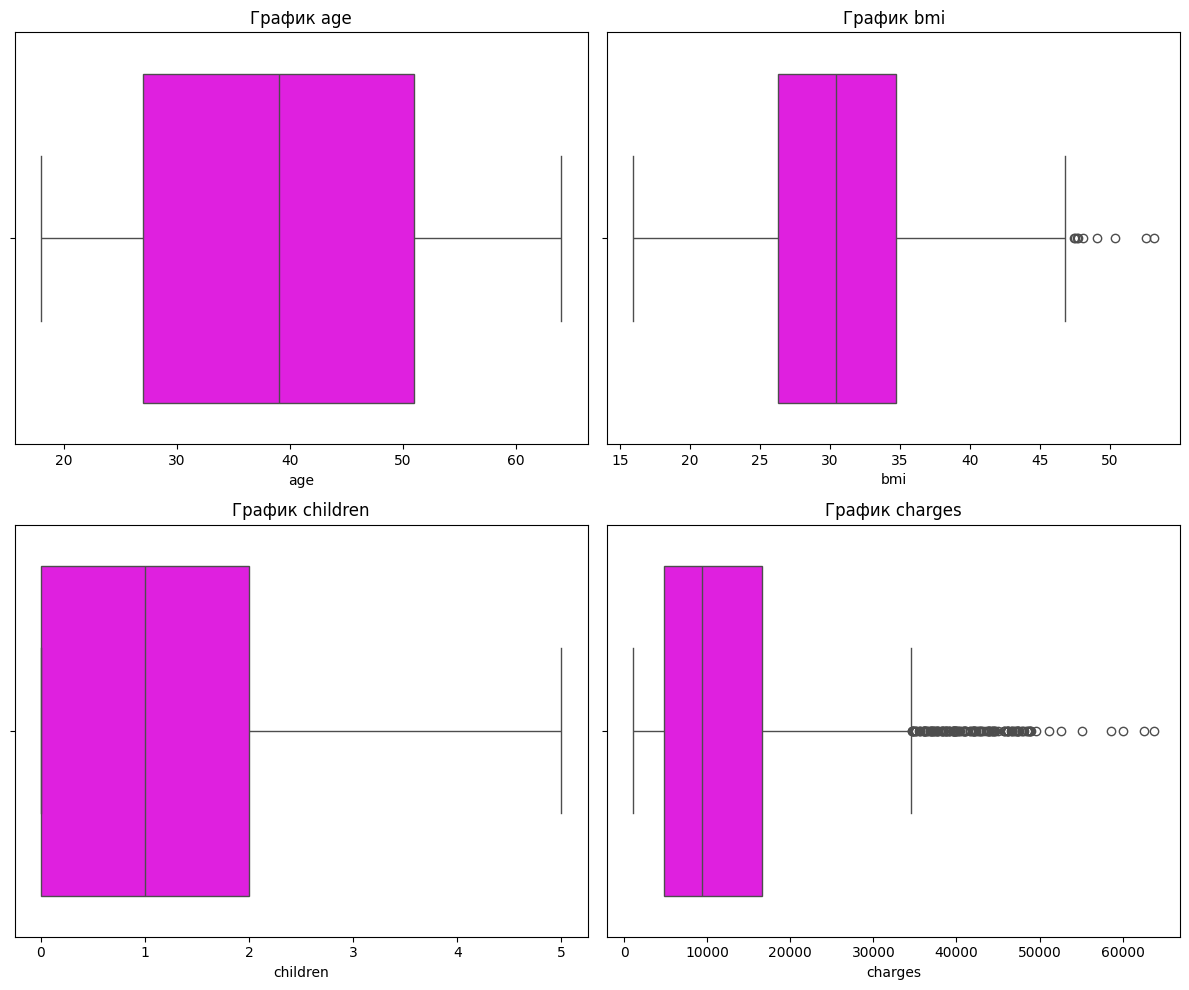


=== Курящие, charges ===
Границы: [-9463.20, 71308.65]
Количество выбросов: 0
Доля выбросов: 0.00%

=== Некурящие, charges ===
Границы: [-7072.32, 22424.22]
Количество выбросов: 46
Доля выбросов: 4.33%


In [ ]:
#Выбросы 1.2.7

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#загрузка данных
df = pd.read_csv('Medical_insurance_clean.csv')

#функция поиска выбросов по IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

#анализ по всем числовым признакам
numeric_cols = ['age', 'bmi', 'children', 'charges']
for col in numeric_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"\n=== {col} ===")
    print(f"Границы: [{lb:.2f}, {ub:.2f}]")
    print(f"Количество выбросов: {len(outliers)}")
    if len(outliers) > 0:
        print("Примеры выбросов:")
        print(outliers[[col]].head())

#визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='fuchsia')
    axes[i].set_title(f'График {col}')
plt.tight_layout()
plt.show()

#учёт курения для charges
smoker_yes = df[df['smoker'] == 'yes']
smoker_no = df[df['smoker'] == 'no']

for group_name, group_data in [('Курящие', smoker_yes), ('Некурящие', smoker_no)]:
    outliers, lb, ub = detect_outliers_iqr(group_data, 'charges')
    print(f"\n=== {group_name}, charges ===")
    print(f"Границы: [{lb:.2f}, {ub:.2f}]")
    print(f"Количество выбросов: {len(outliers)}")
    print(f"Доля выбросов: {len(outliers)/len(group_data)*100:.2f}%")

In [ ]:
#Условная фильтрация сэмплов 1.2.8

import pandas as pd

#загрузка данных
df = pd.read_csv('Medical_insurance_clean.csv')

#фильтр: smoker == 'yes'
smokers = df[df['smoker'] == 'yes']
print(f"Количество курящих клиентов: {len(smokers)}")

#фильтр: age > 50 и bmi > 30
older_obese = df[(df['age'] > 50) & (df['bmi'] > 30)]
print(f"\nКоличество клиентов старше 50 лет с bmi > 30: {len(older_obese)}")

#фильтр: region == 'southeast', children >= 1, smoker == 'yes'
southeast_family_smokers = df[(df['region'] == 'southeast') &
                               (df['children'] >= 1) &
                               (df['smoker'] == 'yes')]
print(f"\nКоличество клиентов (southeast, дети >=1, курящие): {len(southeast_family_smokers)}")


Количество курящих клиентов: 274

Количество клиентов старше 50 лет с bmi > 30: 219

Количество клиентов (southeast, дети >=1, курящие): 51


In [ ]:
#Добавление шума 1.2.9

import pandas as pd
import numpy as np

#загрузка данных
df = pd.read_csv('Medical_insurance_clean.csv')

#параметры шума
noise_scale_age = 2.0   # отклонение для возраста
noise_scale_bmi = 1.5   # отклонение для ИМТ

#копия данных для зашумления
df_noisy = df.copy()

#чтобы везде были одинаковые значения шума
np.random.seed(37)

#добавление шума
df_noisy['age'] = df_noisy['age'] + np.random.normal(0, noise_scale_age, len(df_noisy))
df_noisy['bmi'] = df_noisy['bmi'] + np.random.normal(0, noise_scale_bmi, len(df_noisy))

#ограничение значений разумными пределами
df_noisy['age'] = df_noisy['age'].clip(0, 100)
df_noisy['bmi'] = df_noisy['bmi'].clip(10, 60)

#сохранение в новый файл
df_noisy.to_csv('Medical_insurance_noisy.csv', index=False)

#загрузка исходного и зашумлённого файлов
df_original = pd.read_csv('Medical_insurance_clean.csv')
df_noisy = pd.read_csv('Medical_insurance_noisy.csv')

print("Сравнение исходных и зашумлённых значений (первые 10 строк):")

print("\n--- age ---")
comparison_age = pd.DataFrame({
    'original_age': df_original['age'].head(10),
    'noisy_age': df_noisy['age'].head(10)
})
print(comparison_age)

print("\n--- bmi ---")
comparison_bmi = pd.DataFrame({
    'original_bmi': df_original['bmi'].head(10),
    'noisy_bmi': df_noisy['bmi'].head(10)
})
print(comparison_bmi)

Сравнение исходных и зашумлённых значений (первые 10 строк):

--- age ---
   original_age  noisy_age
0            19  18.891073
1            18  19.348616
2            28  28.693294
3            33  30.399308
4            32  35.037024
5            31  32.979647
6            46  46.555362
7            37  36.102821
8            37  38.923932
9            60  58.344843

--- bmi ---
   original_bmi  noisy_bmi
0        27.900  28.708249
1        33.770  33.318599
2        33.000  32.895370
3        22.705  23.414210
4        28.880  28.789876
5        25.740  25.058329
6        33.440  33.657154
7        27.740  27.301652
8        29.830  29.736713
9        25.840  25.609007


In [ ]:
#Преобразование числовых данных в категориальные 1.2.10

import pandas as pd
import numpy as np

#загрузка данных
df = pd.read_csv('Medical_insurance_noisy.csv')

#возрастные группы
bins_age = [0, 18, 30, 45, 60, 100]
labels_age = ['0-18', '19-30', '31-45', '46-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=False)

#категории BMI по стандартам ВОЗ
bins_bmi = [0, 18.5, 25, 30, 100]
labels_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['bmi_category'] = pd.cut(df['bmi'], bins=bins_bmi, labels=labels_bmi, right=False)

#группировка children: 0, 1, 2, 3+
df['children_group'] = df['children'].apply(lambda x: '3+' if x >= 3 else str(x))

#категории charges (квартили)
q25, q50, q75 = df['charges'].quantile([0.25, 0.5, 0.75])
bins_charges = [0, q25, q50, q75, df['charges'].max()]
labels_charges = ['Low', 'Medium', 'High', 'Very High']
df['charges_category'] = pd.cut(df['charges'], bins=bins_charges, labels=labels_charges, right=False)

#формирование нового датасета
df_final = df[['sex', 'smoker', 'region', 'age_group', 'bmi_category', 'children_group', 'charges_category']]

#сохранение в новый файл
df_final.to_csv('Medical_insurance_categorical.csv', index=False)

#просмотр результата
print(df[['sex', 'smoker', 'region', 'age_group', 'bmi_category', 'children_group', 'charges_category']].head(10))


      sex smoker     region age_group bmi_category children_group  \
0  female    yes  southwest     19-30   Overweight              0   
1    male     no  southeast     19-30        Obese              1   
2    male     no  southeast     19-30        Obese             3+   
3    male     no  northwest     31-45       Normal              0   
4    male     no  northwest     31-45   Overweight              0   
5  female     no  southeast     31-45   Overweight              0   
6  female     no  southeast     46-60        Obese              1   
7  female     no  northwest     31-45   Overweight             3+   
8    male     no  northeast     31-45   Overweight              2   
9  female     no  northwest     46-60   Overweight              0   

  charges_category  
0        Very High  
1              Low  
2              Low  
3        Very High  
4              Low  
5              Low  
6           Medium  
7           Medium  
8           Medium  
9        Very High  


Размер исходного датасета: (2772, 7)
Размер категориального датасета: (1337, 7)


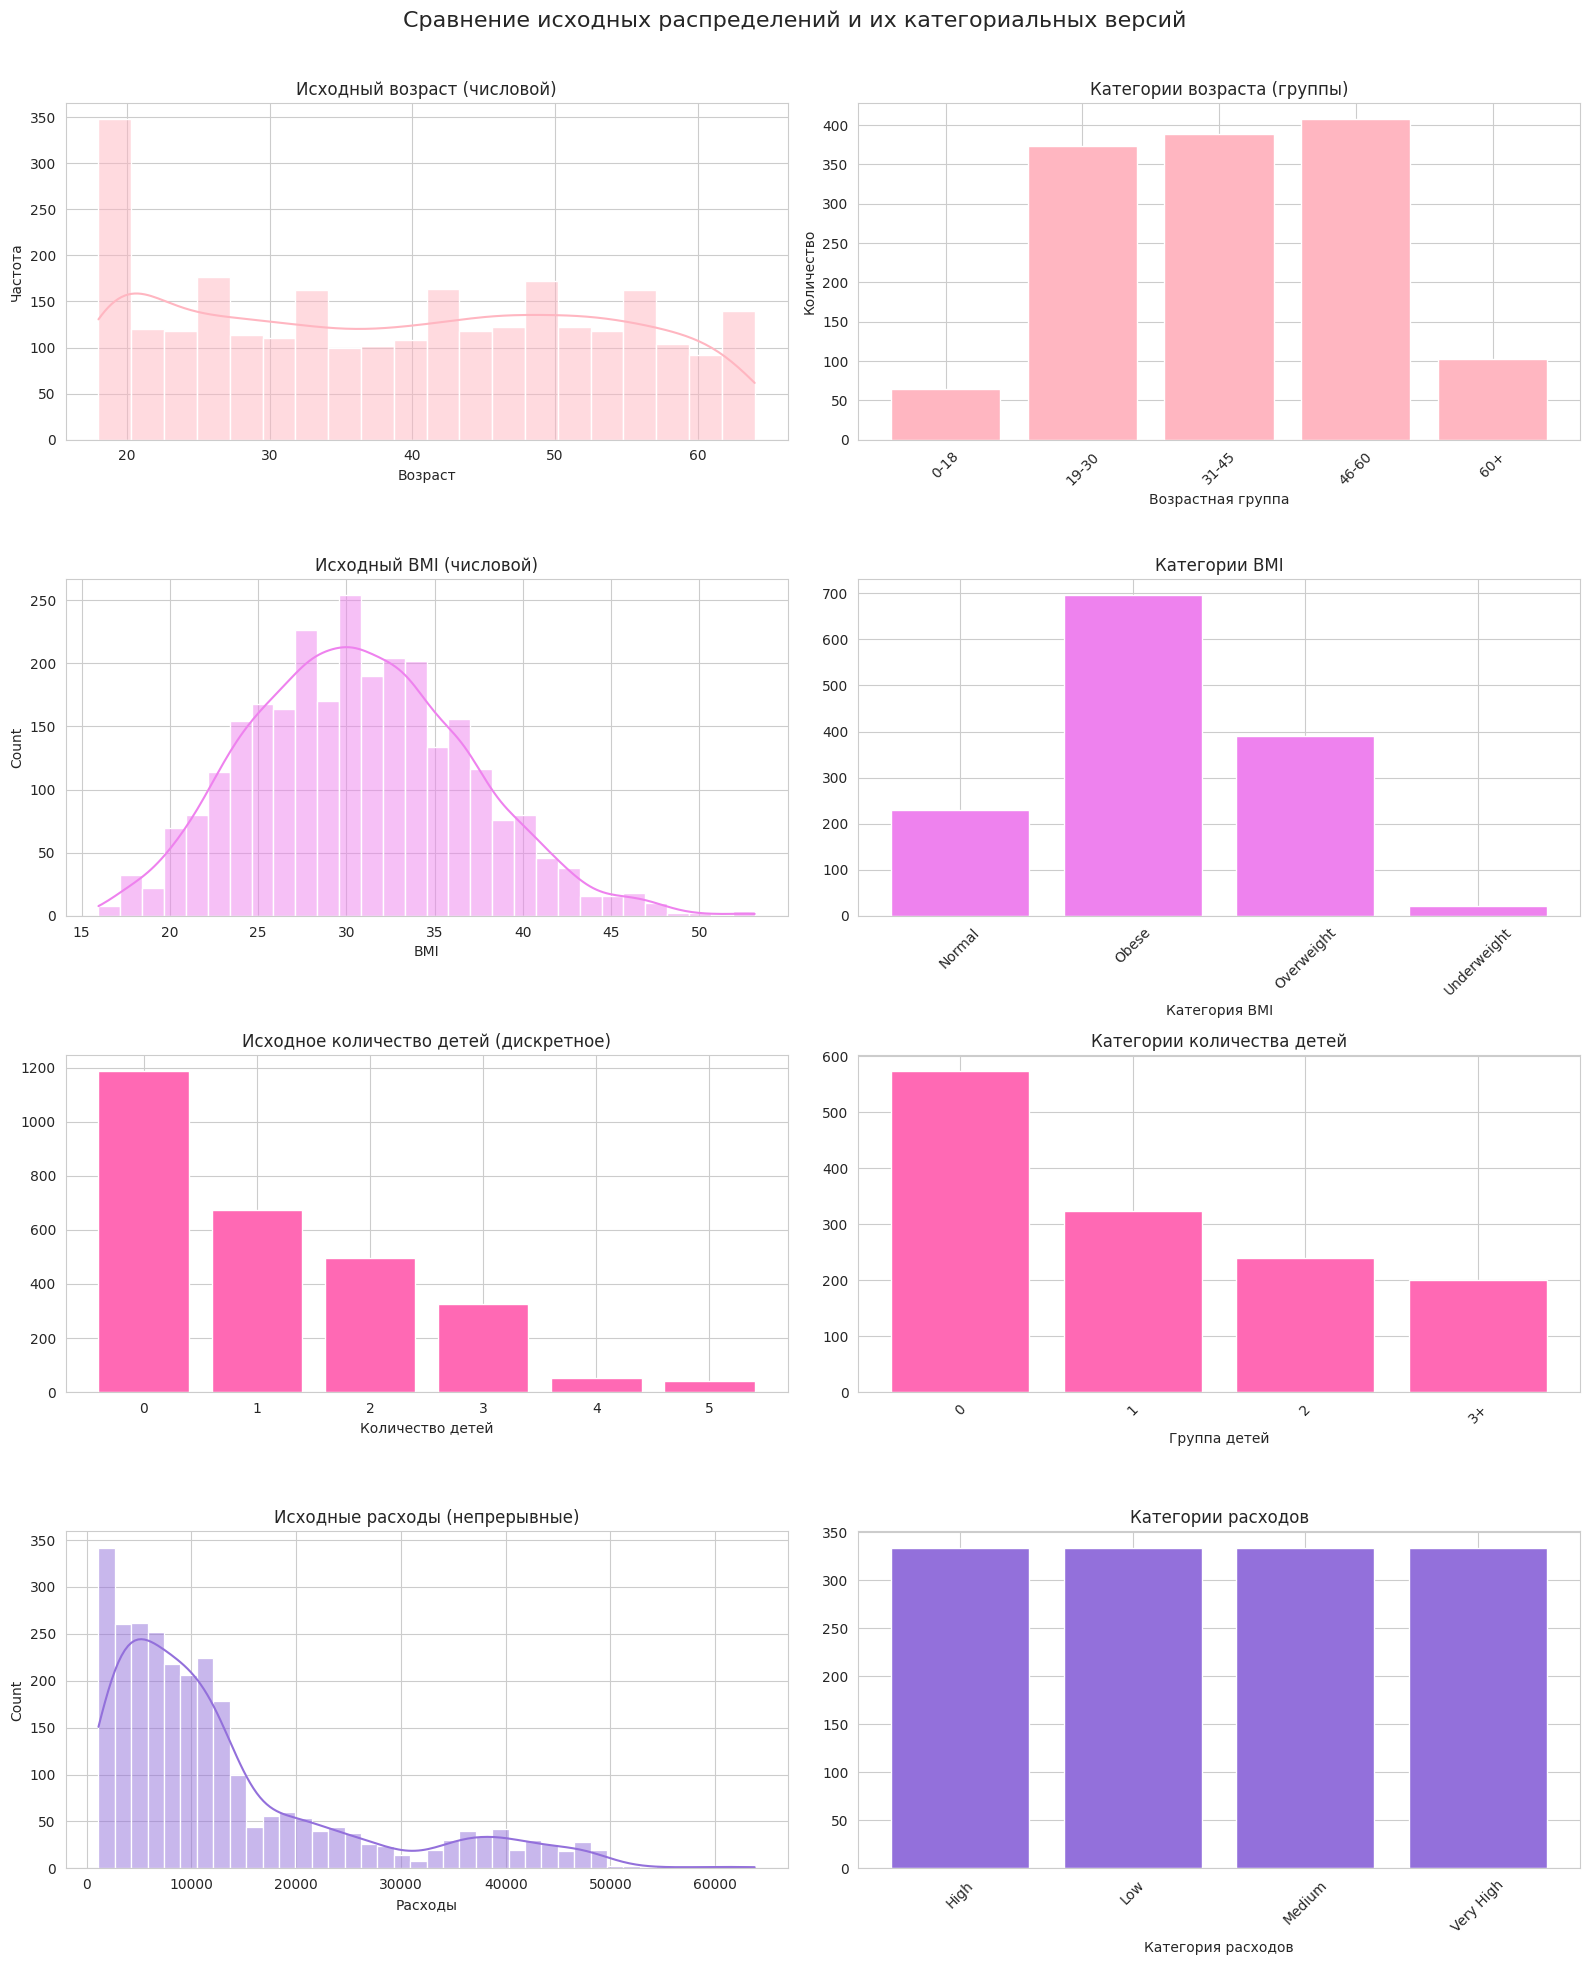


=== Числовые характеристики исходных признаков ===
               age          bmi     children       charges
count  2772.000000  2772.000000  2772.000000   2772.000000
mean     39.109668    30.701349     1.101732  13261.369959
std      14.081459     6.129449     1.214806  12151.768945
min      18.000000    15.960000     0.000000   1121.873900
25%      26.000000    26.220000     0.000000   4687.797000
50%      39.000000    30.447500     1.000000   9333.014350
75%      51.000000    34.770000     2.000000  16577.779500
max      64.000000    53.130000     5.000000  63770.428010

=== Распределение категориальных признаков (в процентах) ===

age_group:
age_group
0-18      4.786836
19-30    27.898280
31-45    29.094989
46-60    30.516081
60+       7.703815
Name: proportion, dtype: float64

bmi_category:
bmi_category
Normal         17.127898
Obese          52.056844
Overweight     29.169783
Underweight     1.645475
Name: proportion, dtype: float64

children_group:
children_group
0     42.857

In [ ]:
#Оценка изменения в данных после фильтрации 1.2.12.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#загрузка данных
df_original = pd.read_csv('Medical_insurance.csv')
df_cat = pd.read_csv('Medical_insurance_categorical.csv')

print("Размер исходного датасета:", df_original.shape)
print("Размер категориального датасета:", df_cat.shape)

#настройка стиля
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

#создание фигуры с 4 строками и 2 столбцами
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Сравнение исходных распределений и их категориальных версий', fontsize=16, y=0.98)

#возраст (age)
ax1 = axes[0, 0]
sns.histplot(df_original['age'], bins=20, kde=True, ax=ax1, color='lightpink')
ax1.set_title('Исходный возраст (числовой)')
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Частота')

ax2 = axes[0, 1]
age_counts = df_cat['age_group'].value_counts().sort_index()
ax2.bar(age_counts.index, age_counts.values, color='lightpink')
ax2.set_title('Категории возраста (группы)')
ax2.set_xlabel('Возрастная группа')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylabel('Количество')

#имт (bmi)
ax1 = axes[1, 0]
sns.histplot(df_original['bmi'], bins=30, kde=True, ax=ax1, color='violet')
ax1.set_title('Исходный BMI (числовой)')
ax1.set_xlabel('BMI')

ax2 = axes[1, 1]
bmi_counts = df_cat['bmi_category'].value_counts().sort_index()
ax2.bar(bmi_counts.index, bmi_counts.values, color='violet')
ax2.set_title('Категории BMI')
ax2.set_xlabel('Категория BMI')
ax2.tick_params(axis='x', rotation=45)

#количество детей (children)
ax1 = axes[2, 0]
children_counts = df_original['children'].value_counts().sort_index()
ax1.bar(children_counts.index, children_counts.values, color='hotpink')
ax1.set_title('Исходное количество детей (дискретное)')
ax1.set_xlabel('Количество детей')
ax1.set_xticks(range(0, 6))

ax2 = axes[2, 1]
child_counts = df_cat['children_group'].value_counts().sort_index()
ax2.bar(child_counts.index, child_counts.values, color='hotpink')
ax2.set_title('Категории количества детей')
ax2.set_xlabel('Группа детей')
ax2.tick_params(axis='x', rotation=45)

#расходы (charges)
ax1 = axes[3, 0]
sns.histplot(df_original['charges'], bins=40, kde=True, ax=ax1, color='mediumpurple')
ax1.set_title('Исходные расходы (непрерывные)')
ax1.set_xlabel('Расходы')

ax2 = axes[3, 1]
charge_counts = df_cat['charges_category'].value_counts().sort_index()
ax2.bar(charge_counts.index, charge_counts.values, color='mediumpurple')
ax2.set_title('Категории расходов')
ax2.set_xlabel('Категория расходов')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#числовые статистики исходных признаков
print("\n=== Числовые характеристики исходных признаков ===")
print(df_original[['age', 'bmi', 'children', 'charges']].describe())

#распределение категориальных признаков (в процентах)
print("\n=== Распределение категориальных признаков (в процентах) ===")
for col in ['age_group', 'bmi_category', 'children_group', 'charges_category']:
    print(f"\n{col}:")
    print(df_cat[col].value_counts(normalize=True).sort_index() * 100)


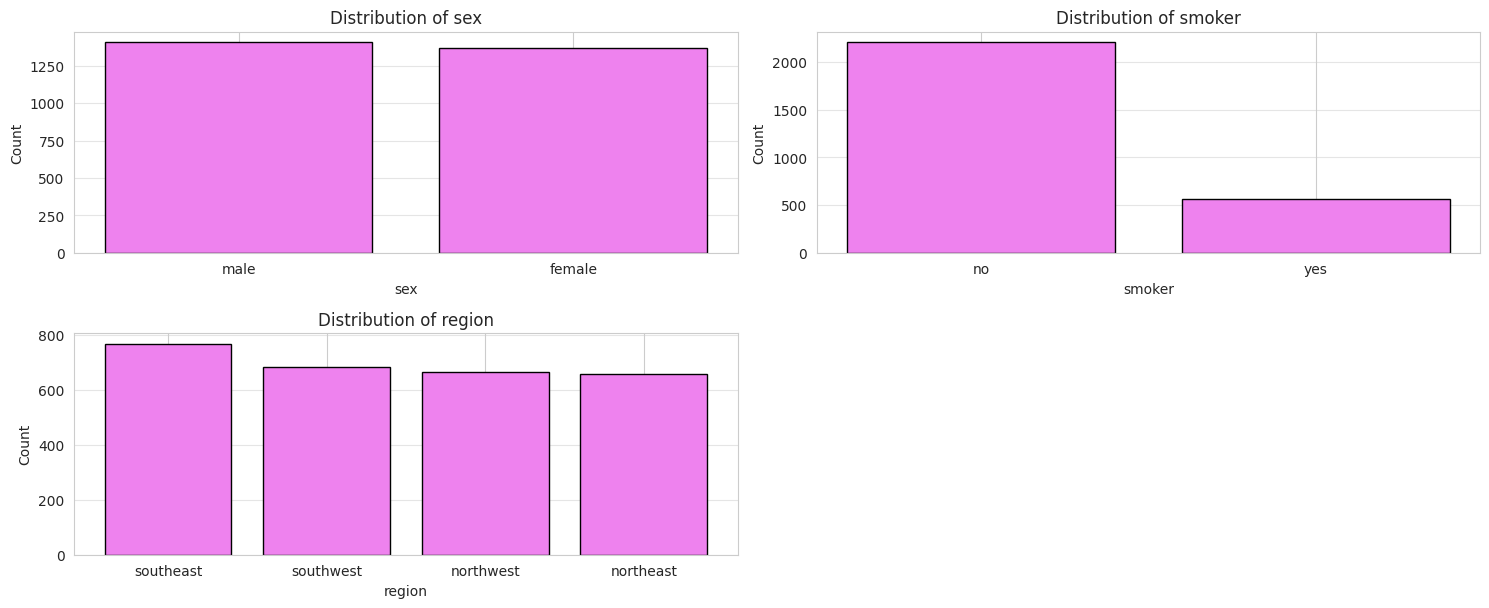

In [ ]:
#Диаграммы распределения категориальных данных 1.3.2

import pandas as pd
import matplotlib.pyplot as plt

#загрузка данных
df = pd.read_csv('Medical_insurance.csv')

categorical_cols = ['sex', 'smoker', 'region'] #текст

#сетка 4x2
plt.figure(figsize=(15, 12))

#категориальные признаки (3 графика)
for i, col in enumerate(categorical_cols, start=len(numeric_cols) + 1):
    plt.subplot(4, 2, i)
    counts = df[col].value_counts()
    plt.bar(counts.index, counts.values, color='violet', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
#Преобразование категориальных данных в числовые 1.3.3.

import pandas as pd
from sklearn.preprocessing import LabelEncoder

#загрузка данных
df = pd.read_csv('Medical_insurance.csv')

#замена значений в столбце sex по заданному правилу
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

#преобразование остальных категориальных столбцов с помощью LabelEncoder
le = LabelEncoder()
df['smoker'] = le.fit_transform(df['smoker'])   #no -> 0, yes -> 1
df['region'] = le.fit_transform(df['region'])   #каждому региону присваивается число

#сохранение результата в новый файл
df.to_csv('medical_insurance_encoded.csv', index=False)

print("Первые 5 строк закодированных данных:")
print(df.head())

Файл 'medical_insurance_encoded.csv' успешно создан.
Первые 5 строк закодированных данных:
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [ ]:
#Введение новой категории 1.3.5.

import pandas as pd

#загрузка данных
df = pd.read_csv('medical_insurance_encoded.csv')

#создание возрастных групп
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100],
                         labels=['молодой', 'средний', 'пожилой'], right=False)

#категории BMI
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 25, 30, 100],
                            labels=['норма', 'избыточный вес', 'ожирение'], right=False)

#определение категории риска
def assign_risk(row):
    if row['smoker'] == 1:
        return 'high'
    else:
        if row['age_group'] == 'пожилой' or row['bmi_category'] == 'ожирение':
            return 'medium'
        elif row['age_group'] == 'medium' and row['bmi_category'] == 'избыточный вес':
            return 'medium'
        else:
            return 'low'

df['risk_category'] = df.apply(assign_risk, axis=1)

#удаление временных столбцов
df.drop(['age_group', 'bmi_category'], axis=1, inplace=True)

#сохранение результата
df.to_csv('medical_insurance_with_risk.csv', index=False)

print("Первые 5 строк закодированных данных:")
print(df.head())

Первые 5 строк закодированных данных:
   age  sex     bmi  children  smoker  region      charges risk_category
0   19    0  27.900         0       1       3  16884.92400          high
1   18    1  33.770         1       0       2   1725.55230        medium
2   28    1  33.000         3       0       2   4449.46200        medium
3   33    1  22.705         0       0       1  21984.47061           low
4   32    1  28.880         0       0       1   3866.85520           low
